

1.**Artificial Intelligence(AI):**
AI is a broad field of computer science that enables machines to perform tasj=ks that normally requires human intelligence.

**Real-world example:**
A hospital ai system can analyze a patients medical information and helps doctors to identify whether the patient suffering with diabetes.

2.**Machine Learning(ML)**:
Machine Learning is a subset of AI where computers learn patterns from existing data and use those patterns to make predictions

**Real-world example:**
A diabetes prediction model can learn from previous patients' glucose levels, BMI, age, blood pressure, etc., and predict whether a new patient is likely to have diabetes.

**3.Deep Learning(DL):**
Deep Learning is a subset of Machine Learning that uses artificial neural networks with multiple layers to learn complex patterns from data.

**Real-world example:**
A deep learning model can analyze medical images such as X-rays or scans to assist doctors in identifying diseases.








**MACHINE LEARNING WORKFLOW**


**1. Data Collection**

**2. Data Cleaning**

**3. Exploratory Data Analysis (EDA)**

**4. Feature Engineering**

**5. Train-Test Split**

**6. Model Training**

**7. Prediction**

**8. Evaluation**

**9. Deployment**


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score, confusion_matrix,classification_report)
import joblib

In [5]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
def clean_data(df):
    df = df.copy()
    columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    df[columns] = df[columns].replace(0, np.nan)
    df[columns] = df[columns].fillna(df[columns].median())
    df = df.drop_duplicates()
    return df

In [12]:
df=clean_data(df)

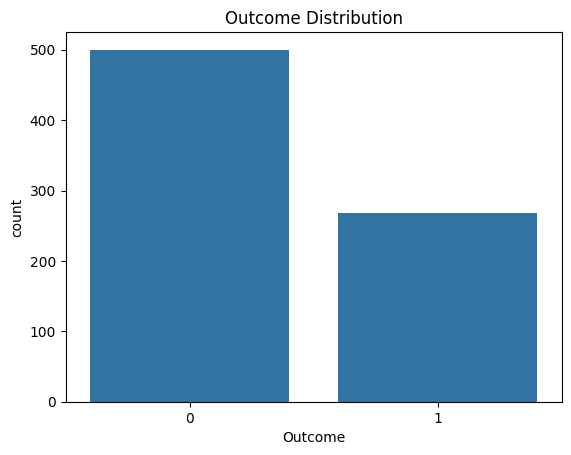

In [15]:
#Outcome distribution
sns.countplot(x="Outcome",data=df)
plt.title("Outcome Distribution")
plt.show()

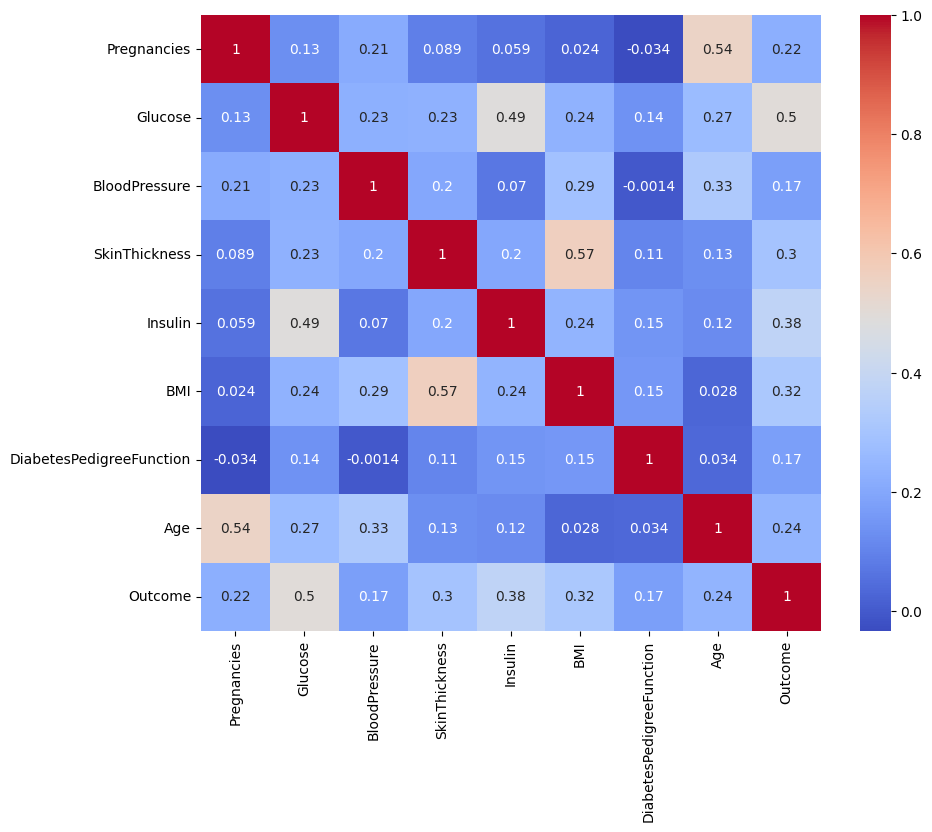

In [16]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [17]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [18]:
def split_data(X,y):
    return train_test_split( X,y,test_size=0.20,random_state=42)

In [19]:
X_train,X_test,y_train,y_test = split_data(X,y)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
def train_model(model,X_train,y_train):
    model.fit(X_train,y_train)
    return model

In [22]:
lr = train_model(LogisticRegression(max_iter=1000),X_train_scaled,y_train)

In [23]:
knn = train_model(KNeighborsClassifier(),X_train_scaled,y_train)

In [24]:
dt = train_model(DecisionTreeClassifier(random_state=42),X_train,y_train)

In [25]:
def predict(model,data):
    return model.predict(data)

In [26]:
lr_pred = predict(lr,X_test_scaled)
knn_pred = predict(knn,X_test_scaled)
dt_pred = predict(dt,X_test)

In [30]:
def evaluate(y_true,y_pred):
    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision :",precision_score(y_true,y_pred))
    print("Recall :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))
    print("Confusion Matrix")
    print(confusion_matrix(y_true,y_pred))

In [31]:
print("Logistic Regression")
evaluate(y_test,lr_pred)

Logistic Regression
Accuracy : 0.7727272727272727
Precision : 0.6923076923076923
Recall : 0.6545454545454545
F1 Score : 0.6728971962616822
Confusion Matrix
[[83 16]
 [19 36]]


In [32]:
print("KNN")
evaluate(y_test,knn_pred)

KNN
Accuracy : 0.7987012987012987
Precision : 0.6935483870967742
Recall : 0.7818181818181819
F1 Score : 0.7350427350427351
Confusion Matrix
[[80 19]
 [12 43]]


In [33]:
print("Decision Tree")
evaluate(y_test,dt_pred)

Decision Tree
Accuracy : 0.8376623376623377
Precision : 0.75
Recall : 0.8181818181818182
F1 Score : 0.782608695652174
Confusion Matrix
[[84 15]
 [10 45]]


In [34]:
def save_model(model,file_name):
    joblib.dump(model,file_name)
    print("Model Saved Successfully")

In [35]:
save_model(lr,"diabetes_model.pkl")

Model Saved Successfully


In [36]:
model = joblib.load("diabetes_model.pkl")

In [39]:
preg = float(input("Pregnancies: "))
glu = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
ins = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))

Pregnancies: 2
Glucose: 120
Blood Pressure: 70
Skin Thickness: 20
Insulin: 85
BMI: 28.5
Diabetes Pedigree Function: 0.35
Age: 25


In [40]:
new_data = pd.DataFrame([[preg,glu,bp,skin,ins,bmi,dpf,age]],
columns=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"])
new_data = scaler.transform(new_data)
prediction = model.predict(new_data)
if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Not Diabetic


Accuracy:

Measures the overall percentage of correct predictions.

Precision:

Measures how many predicted diabetic patients are actually diabetic.

Recall:

Measures how many actual diabetic patients are correctly identified.

F1 Score:

The harmonic mean of Precision and Recall.

Confusion Matrix:

Shows the number of correct and incorrect predictions.

Conclusion:

In this project, a Machine Learning application was developed to predict diabetes using the Pima Indians Diabetes Dataset. The dataset was cleaned, explored, and prepared for training. Three machine learning models—Logistic Regression, K-Nearest Neighbors (KNN), and Decision Tree—were trained and evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix. The trained model was saved using the joblib library and used to predict whether a new patient is diabetic based on user-provided medical information.